# Food Price Inflation in Nigeria: Trends, Patterns, and Potential Drivers

**Study period:** January 2025 - May 2026 (17 months)
**Scope:** Nigeria-wide, national level

## Why this project

Food prices are something I notice regularly, so I started wondering why some foods change much more in price than others. I also noticed that food inflation could move differently from overall inflation. I wanted to look beyond the headline number and see which foods and food categories changed the most, and whether factors such as exchange rates and petrol prices were associated with those changes. I used publicly available Nigerian data to investigate these patterns.

## Research question

How did food prices in Nigeria change from January 2025 to May 2026, which foods and food categories changed the most during that period, and which potential economic factors were associated with the movement?

## Why January 2025 - May 2026

I chose this window because it captures a clear change in food inflation:
Food inflation eased through most of 2025, reached its lowest point in the study period in early 2026, and then started rising again. This lets me examine both the decline and the reversal within the same period.

This period also gives me monthly data for the main variables used in the analysis, so they can be compared month by month.

## Data sources

| Dataset | Source | Frequency | Period | Purpose |
|---|---|---|---|---|
| Headline inflation | NBS | Monthly | Jan 2025 - May 2026 | Overall inflation trend |
| Food inflation | NBS | Monthly | Jan 2025 - May 2026 | Food-specific inflation trend |
| Selected food prices (42 items) | NBS Food Price Watch | Monthly | Jan 2025 - May 2026 | Individual food & category analysis |
| Exchange rate (USD/NGN) | investing.com | Monthly | Jan 2025 - May 2026 | Potential driver |
| Petrol (PMS) price | NBS | Monthly | Jan 2025 - May 2026 | Potential driver |

**Note:** I tried to obtain the exchange-rate data directly from CBN, but I could not get a usable monthly series from the site. I therefore used monthly closing USD/NGN rates from Investing.com. This is a market-quoted proxy rather than an official CBN series.

## Method

The analysis uses food-price trends, category comparisons, correlations, and an exploratory regression. Exchange rate and petrol price were tested as potential drivers after screening the available data. Results are interpreted as associations rather than causal effects.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import datetime

## Step 1: The overall pattern

I first compare headline inflation with food inflation to see how differently they moved during the study period.

In [2]:
# Skip the first four rows containing table headers and weights
raw = pd.read_excel("cpi_1New_June2026.xlsx", sheet_name="Table1", header=None)
data = raw.iloc[4:].copy()
data.columns = range(data.shape[1])

# The year is listed only once, so fill it down for the remaining months
data[0] = data[0].ffill()

cpi = pd.DataFrame({
    "year": data[0].astype(int),
    "month": data[1],
    "all_items_yoy": data[5],
    "food_yoy": data[15]
}).reset_index(drop=True)

# Keep the study period: January 2025 to May 2026
cpi = cpi[(cpi["year"] > 2024) & ~((cpi["year"] == 2026) & (cpi["month"] == "June"))]
cpi = cpi.reset_index(drop=True)
cpi

C:\Users\DAVID\AppData\Local\Temp\ipykernel_3708\1828559040.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[0] = data[0].ffill()


,year,month,all_items_yoy,food_yoy
0,2025,Jan,27.606151,29.625233
1,2025,Feb,26.274415,26.98238
2,2025,Mar,27.350063,25.219883
3,2025,Apr,26.81593,24.675047
4,2025,May,26.061316,24.554118
5,2025,Jun,25.286661,25.407808
6,2025,Jul,24.940533,26.195647
7,2025,Aug,23.141652,25.304828
8,2025,Sep,20.980827,20.161952
9,2025,Oct,18.967917,16.302009


### A quick sanity check on this data

Before plotting, I checked the number of rows, missing values, date range, and duplicate records.

In [3]:
print("rows, columns:", cpi.shape)
print("date range:", cpi['month'].iloc[0], cpi['year'].iloc[0], "to", cpi['month'].iloc[-1], cpi['year'].iloc[-1])
print("missing values:\n", cpi.isna().sum())
print("duplicate rows:", cpi.duplicated().sum())

rows, columns: (17, 4)
date range: Jan 2025 to May 2026
missing values:
 year             0
month            0
all_items_yoy    0
food_yoy         0
dtype: int64
duplicate rows: 0


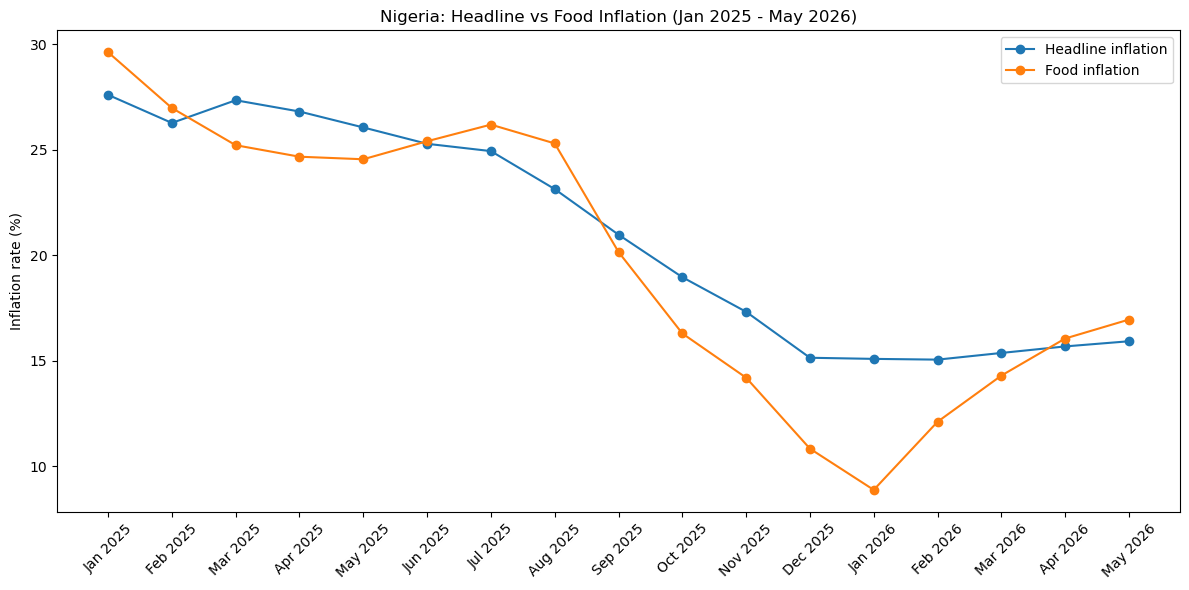

In [4]:
labels = cpi["month"] + " " + cpi["year"].astype(str)

plt.figure(figsize=(12, 6))
plt.plot(labels, cpi["all_items_yoy"], marker="o", label="Headline inflation")
plt.plot(labels, cpi["food_yoy"], marker="o", label="Food inflation")
plt.xticks(rotation=45)
plt.ylabel("Inflation rate (%)")
plt.title("Nigeria: Headline vs Food Inflation (Jan 2025 - May 2026)")
plt.legend()
plt.tight_layout()
plt.show()

## Step 2: Zooming into individual foods

The food inflation series does not show how individual food prices changed. I therefore use the item-level data to examine individual foods before comparing all 42 items and their categories.

### Building the food price dataset

The NBS Food Price Watch data is provided in separate monthly files, so I combined the reports into one table for analysis.

In [6]:
import requests, zipfile, io, time

# NBS provides the Food Price Watch data in separate monthly files
files_to_get = [
    {"month": "Jan 2025", "url": "https://microdata.nigerianstat.gov.ng/index.php/catalog/162/download/1230/Selected_food_table_Jan25.xlsx", "zipped": False},
    {"month": "Feb 2025", "url": "https://microdata.nigerianstat.gov.ng/index.php/catalog/162/download/1239/selected_food_table_Feb_25.xlsx", "zipped": False},
    {"month": "Mar 2025", "url": "https://microdata.nigerianstat.gov.ng/index.php/catalog/162/download/1240/selected_food_table_Mar_25.xlsx", "zipped": False},
    {"month": "Apr 2025", "url": "https://microdata.nigerianstat.gov.ng/index.php/catalog/162/download/1231/selected_food_table_Apr25.xlsx", "zipped": False},
    {"month": "May 2025", "url": "https://microdata.nigerianstat.gov.ng/index.php/catalog/162/download/1282/Selected_Food_Report_May_2025.zip", "zipped": True},
    {"month": "Jun 2025", "url": "https://microdata.nigerianstat.gov.ng/index.php/catalog/162/download/1283/Selected_Food_Report_June_2025.zip", "zipped": True},
    {"month": "Jul 2025", "url": "https://microdata.nigerianstat.gov.ng/index.php/catalog/162/download/1284/Selected_Food_Report_July_2025.zip", "zipped": True},
    {"month": "Aug-Sep 2025", "url": "https://microdata.nigerianstat.gov.ng/index.php/catalog/162/download/1310/SELECTED_FOOD_PRICES_AUG_SEPT_2025.zip", "zipped": True},
    {"month": "Oct 2025", "url": "https://microdata.nigerianstat.gov.ng/index.php/catalog/162/download/1319/Selected_Food%20Report_Oct25.zip", "zipped": True},
    {"month": "Nov 2025", "url": "https://microdata.nigerianstat.gov.ng/index.php/catalog/162/download/1343/Selected_Food_Report_Nov_25.zip", "zipped": True},
    {"month": "Dec 2025", "url": "https://microdata.nigerianstat.gov.ng/index.php/catalog/162/download/1356/Selected_Food_Report_Dec_25.zip", "zipped": True},
    {"month": "Jan 2026", "url": "https://microdata.nigerianstat.gov.ng/index.php/catalog/162/download/1365/Selected_Food_Report_Jan26.zip", "zipped": True},
    {"month": "Feb 2026", "url": "https://microdata.nigerianstat.gov.ng/index.php/catalog/162/download/1379/Selected_Food_Report_Feb_2026.zip", "zipped": True},
    {"month": "Mar 2026", "url": "https://microdata.nigerianstat.gov.ng/index.php/catalog/162/download/1401/Selected_Food_Report_Mar_2026.zip", "zipped": True},
    {"month": "Apr 2026", "url": "https://microdata.nigerianstat.gov.ng/index.php/catalog/162/download/1415/Selected_Food_Report_April_2026.zip", "zipped": True},
    {"month": "May 2026", "url": "https://microdata.nigerianstat.gov.ng/index.php/catalog/162/download/1427/Selected_Food_Report_May%2026.zip", "zipped": True},
]

monthly_tables = []

for entry in files_to_get:
    print(f"Downloading {entry['month']}...")
    for attempt in range(3):
        try:
            response = requests.get(entry["url"], timeout=60)
            if entry["zipped"]:
                z = zipfile.ZipFile(io.BytesIO(response.content))
                xlsx_name = [n for n in z.namelist() if n.endswith(".xlsx")][0]
                raw_bytes = z.read(xlsx_name)
            else:
                raw_bytes = response.content

            df = pd.read_excel(io.BytesIO(raw_bytes), sheet_name=0)
            df = df.rename(columns={"Item Labels": "Item Label"})

            # a couple of item names have inconsistent spacing/punctuation across months - cleaning that up
            df["Item Label"] = df["Item Label"].str.strip().str.rstrip(",").str.strip()

            avg_cols = [c for c in df.columns if str(c).startswith("Average of")]
            current_col = avg_cols[-1]

            cleaned = df[["Item Label", current_col]].copy()
            cleaned.columns = ["item", entry["month"]]
            monthly_tables.append(cleaned.set_index("item"))
            print(f"  got it, {len(cleaned)} items")
            break
        except Exception as e:
            print(f"  attempt {attempt+1} failed: {e}")
            time.sleep(2)

food_clean = pd.concat(monthly_tables, axis=1).reset_index()
food_clean.to_csv("food_data/combined_food_prices.csv", index=False)
print("done, shape:", food_clean.shape)
food_clean.head()

  got it, 42 items
  got it, 42 items
  got it, 42 items
  got it, 42 items
  got it, 42 items
  got it, 42 items
  got it, 42 items
  got it, 42 items
  got it, 42 items
  got it, 42 items
  got it, 42 items
  got it, 42 items
  got it, 42 items
  got it, 42 items
  got it, 42 items
  got it, 42 items
done, shape: (42, 17)


,item,Jan 2025,Feb 2025,Mar 2025,Apr 2025,May 2025,Jun 2025,Jul 2025,Aug-Sep 2025,Oct 2025,Nov 2025,Dec 2025,Jan 2026,Feb 2026,Mar 2026,Apr 2026,May 2026
0,Agric hen eggs,248.041391,251.940517,261.182346,259.316152,265.725250,268.132191,270.770593,248.215446,252.790552,244.965338,240.956847,240.163279,248.349281,256.484920,259.218195,261.141762
1,"Agric hen eggs, (a Crate of 30 pieces)",5878.140647,5976.115852,7670.559190,6150.178072,6263.915592,6326.553236,6294.291026,5897.874998,5993.009132,5966.166355,5927.106264,5923.164846,6007.352086,6127.617010,6143.112662,6149.177995
2,Beans Brown,2458.533288,2465.962772,2616.263611,2429.388572,2385.151863,2319.993512,2319.265382,1815.759028,1760.527697,1547.027746,1250.111435,1262.425991,1307.443052,1325.853877,1338.932829,1344.931905
3,Beans white,2123.852994,2114.329236,2215.107057,2097.309931,2040.508123,2030.076033,2020.961934,1623.423953,1587.817396,1430.582470,1200.877693,1209.909303,1255.133441,1276.633773,1291.331451,1297.177235
4,Beef Boneless,6122.568294,6269.458819,6523.500991,6544.536858,6662.924662,6808.960907,6831.352774,6861.246548,6850.509670,6908.218147,6885.086263,6874.171309,6893.872839,6903.310592,6919.937600,7171.408124


### Checking that the 42 items are actually usable

I checked whether all 42 items were reported in every month before using them in the analysis.

In [7]:
month_cols = [c for c in food_clean.columns if c != "item"]
coverage = food_clean.set_index("item")[month_cols].notna().sum(axis=1)
coverage = coverage.sort_values()

print("reporting periods available per item (out of", len(month_cols), "possible):")
print(coverage)
print()
print("items with full coverage:", (coverage == len(month_cols)).sum(), "out of", len(coverage))

reporting periods available per item (out of 16 possible):
item
Agric hen eggs                                 16
Maize (Corn) Grains (White) sold loose         16
Onions, fresh                                  16
Palm oil, 75cl                                 16
Plantain (ripe)                                16
Plantain (unripe)                              16
Rice Local, short-Grained                      16
Rice Long-Grained (Imported)                   16
Semovita, Prepacked (1kg)                      16
Smoked fish (Mackerel)                         16
Sweet potatoes                                 16
Tilapia fresh fish (Epiya)                     16
Tin Milk-Evaporated, Peak Milk, 150g           16
Tin Milk-Evaporated, Three Crown Milk, 160g    16
Titus, frozen                                  16
Tomatoes, fresh                                16
Vegetable Oil, 75cl                            16
Watermelon whole, medium size fresh            16
Mackerel, Frozen                    

All 42 items were reported in every month, so no items were removed. Missing values were not imputed.

### Examples of individual food-price trends

I show four foods here as examples rather than plotting all 42 on one chart. The ranking and category analysis below use the full set.

In [8]:
# Show four example foods rather than all 42 to keep the chart readable
items_to_check = [
    "Rice Long-Grained (Imported)",
    "Wheat Flour, Prepacked (2kg)",
    "Garri white",
    "Yam Tuber"
]

subset = food_clean[food_clean["item"].isin(items_to_check)]
subset_long = subset.melt(id_vars="item", var_name="month", value_name="price")
subset_long.head()

,item,month,price
0,Garri white,Jan 2025,1267.634881
1,Rice Long-Grained (Imported),Jan 2025,2505.479399
2,"Wheat Flour, Prepacked (2kg)",Jan 2025,3847.365692
3,Yam Tuber,Jan 2025,1991.329939
4,Garri white,Feb 2025,1277.247070


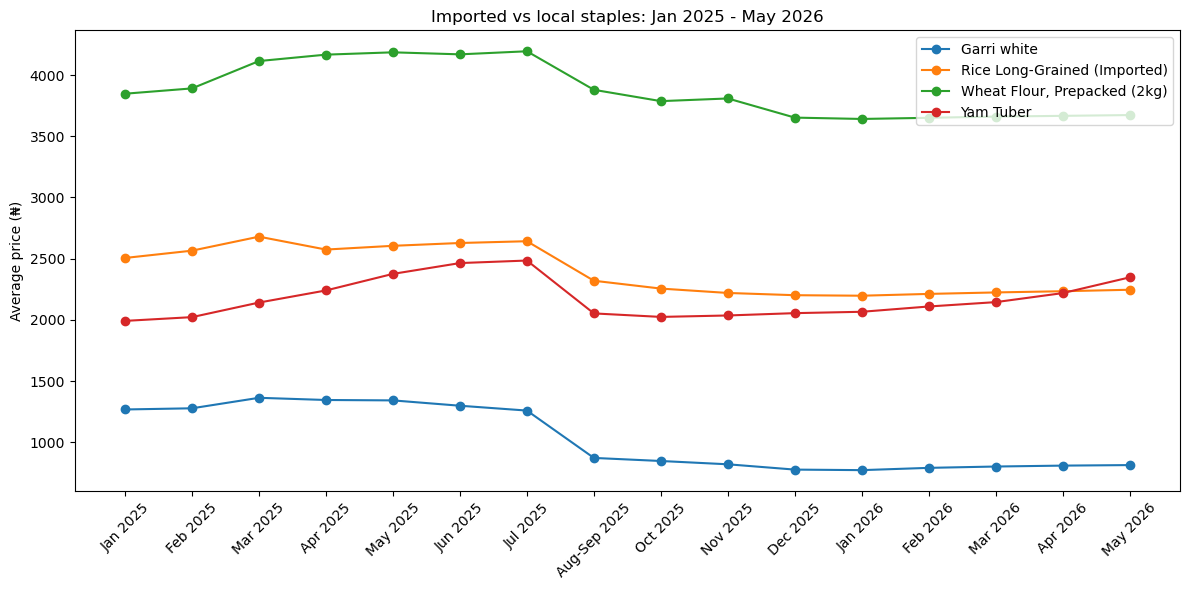

In [9]:
plt.figure(figsize=(12, 6))
for item_name, group in subset_long.groupby("item"):
    plt.plot(group["month"], group["price"], marker="o", label=item_name)

plt.xticks(rotation=45)
plt.ylabel("Average price (₦)")
plt.title("Imported vs local staples: Jan 2025 - May 2026")
plt.legend()
plt.tight_layout()
plt.show()

### Which individual foods actually changed the most?

I then rank all 42 foods by their percentage price change from January 2025 to May 2026.

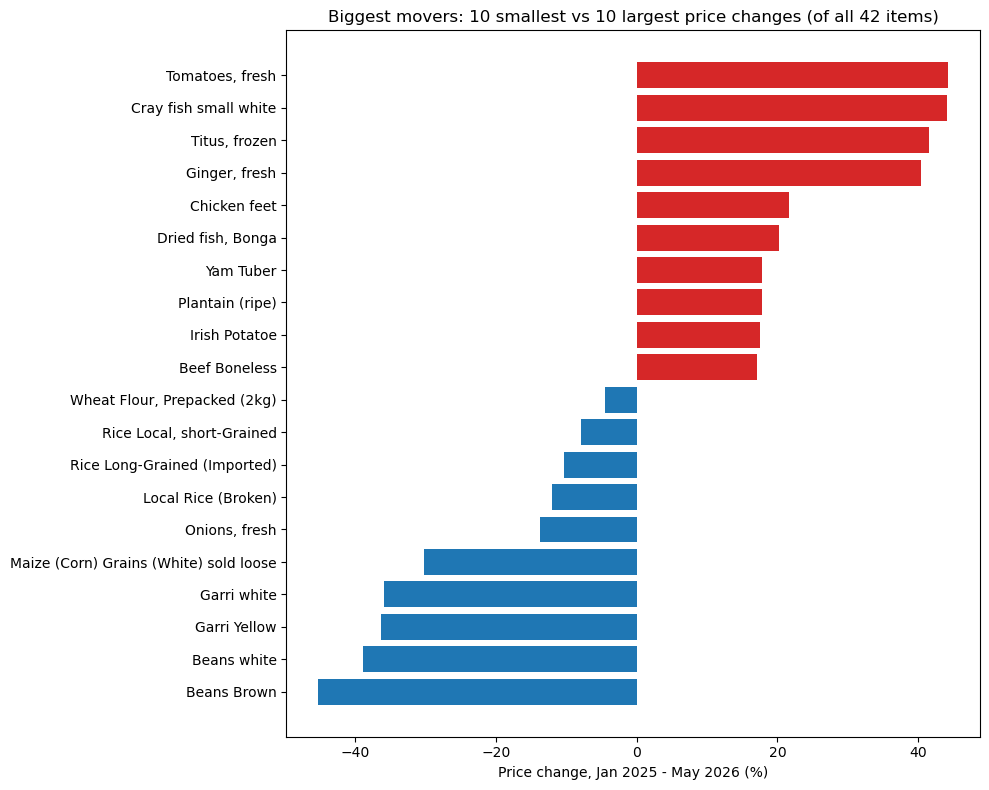

In [10]:
# Calculate each food's percentage price change from January 2025 to May 2026
food_clean["full_period_change"] = (
    (food_clean["May 2026"] - food_clean["Jan 2025"]) / food_clean["Jan 2025"] * 100
)

ranked = food_clean[["item", "full_period_change"]].sort_values("full_period_change")
bottom10 = ranked.head(10)
top10 = ranked.tail(10)
top_bottom = pd.concat([bottom10, top10])

plt.figure(figsize=(10, 8))
colors = ["tab:blue" if v < 0 else "tab:red" for v in top_bottom["full_period_change"]]
plt.barh(top_bottom["item"], top_bottom["full_period_change"], color=colors)
plt.xlabel("Price change, Jan 2025 - May 2026 (%)")
plt.title("Biggest movers: 10 smallest vs 10 largest price changes (of all 42 items)")
plt.tight_layout()
plt.show()

## Step 3: Comparing food categories

I grouped the 42 foods into broad categories to compare how prices changed during the reversal. These are my own analytical groupings, not official NBS categories. Each food was assigned based on its type.

The category number below is a simple average of each item's percentage
change within that category. I did not use expenditure weights because
these are my analytical categories rather than official NBS categories.

I compare January 2026 with May 2026 to measure the price changes during the reversal.

In [11]:
# Analytical grouping of the 42 foods; these are not official NBS categories
category_map = {
    "Local Rice (Broken)": "Grains & Staples",
    "Rice Local, short-Grained": "Grains & Staples",
    "Rice Long-Grained (Imported)": "Grains & Staples",
    "Garri white": "Grains & Staples",
    "Garri Yellow": "Grains & Staples",
    "Yam Tuber": "Grains & Staples",
    "Semovita, Prepacked (1kg)": "Grains & Staples",
    "Wheat Flour, Prepacked (2kg)": "Grains & Staples",
    "Maize (Corn) Grains (White) sold loose": "Grains & Staples",

    "Beans Brown": "Legumes",
    "Beans white": "Legumes",
    "Groundnuts, roasted,75cl bottle": "Legumes",

    "Beef Boneless": "Meat & Poultry",
    "Goat Meat Bone in": "Meat & Poultry",
    "Chicken meat (Frozen)": "Meat & Poultry",
    "Chicken Wings": "Meat & Poultry",
    "Chicken feet": "Meat & Poultry",

    "Cat fresh fish": "Fish & Seafood",
    "Dried fish, Bonga": "Fish & Seafood",
    "Mackerel, Frozen": "Fish & Seafood",
    "Smoked fish (Mackerel)": "Fish & Seafood",
    "Tilapia fresh fish (Epiya)": "Fish & Seafood",
    "Titus, frozen": "Fish & Seafood",
    "Cray fish small white": "Fish & Seafood",

    "Agric hen eggs": "Eggs & Dairy",
    "Agric hen eggs, (a Crate of 30 pieces)": "Eggs & Dairy",
    "Tin Milk-Evaporated, Peak Milk, 150g": "Eggs & Dairy",
    "Tin Milk-Evaporated, Three Crown Milk, 160g": "Eggs & Dairy",

    "Groundnut oil, 75cl": "Oils",
    "Palm oil, 75cl": "Oils",
    "Vegetable Oil, 75cl": "Oils",

    "Carrots, fresh": "Vegetables",
    "Onions, fresh": "Vegetables",
    "Tomatoes, fresh": "Vegetables",
    "Irish Potatoe": "Vegetables",
    "Sweet potatoes": "Vegetables",
    "Ginger, fresh": "Vegetables",

    "Plantain (ripe)": "Fruits",
    "Plantain (unripe)": "Fruits",
    "Watermelon whole, medium size fresh": "Fruits",

    "Bread (sliced), 450g": "Bakery",
    "Bread (unsliced), 450g": "Bakery",
}

food_clean["category"] = food_clean["item"].map(category_map)

# Check that every food item is included before calculating category changes
food_clean[food_clean["category"].isna()]

,item,Jan 2025,Feb 2025,Mar 2025,Apr 2025,May 2025,Jun 2025,Jul 2025,Aug-Sep 2025,Oct 2025,Nov 2025,Dec 2025,Jan 2026,Feb 2026,Mar 2026,Apr 2026,May 2026,full_period_change,category


In [12]:
len(food_clean[food_clean["category"].isna()])

0

In [13]:
# Calculate each item's percentage price change from January to May 2026
food_clean["change_since_trough"] = (
    (food_clean["May 2026"] - food_clean["Jan 2026"]) / food_clean["Jan 2026"] * 100
)

category_change = food_clean.groupby("category")["change_since_trough"].mean().sort_values(ascending=False)
category_change

category
Vegetables          15.795134
Fruits               5.118116
Legumes              5.010840
Fish & Seafood       4.411000
Eggs & Dairy         3.993320
Grains & Staples     3.714422
Meat & Poultry       1.991504
Bakery               1.403605
Oils                 1.356264
Name: change_since_trough, dtype: float64

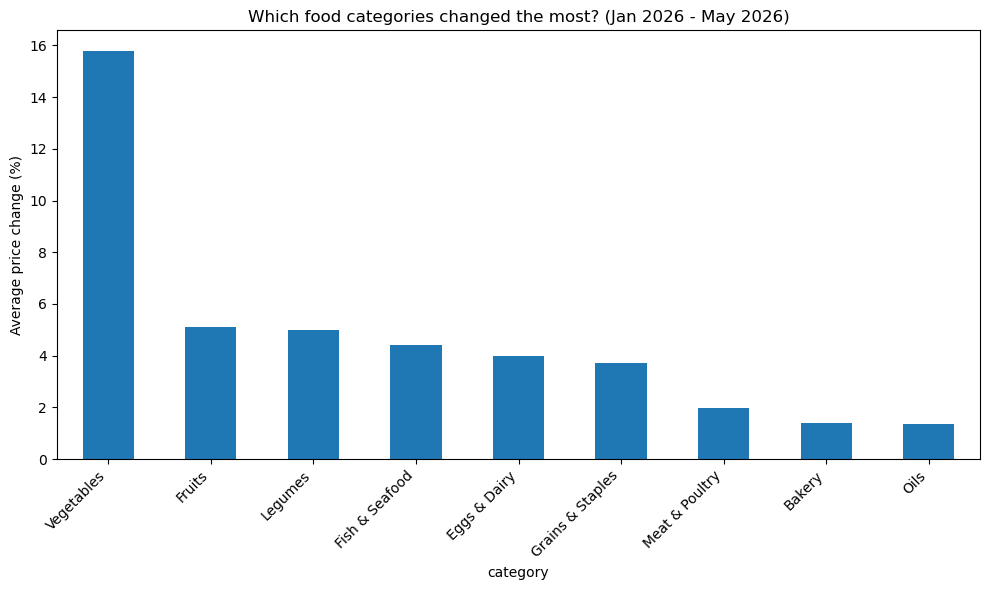

In [14]:
plt.figure(figsize=(10, 6))
category_change.plot(kind="bar")
plt.ylabel("Average price change (%)")
plt.title("Which food categories changed the most? (Jan 2026 - May 2026)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Did every category move together, or was it concentrated?

The previous chart compares only January and May 2026. This chart shows the category trends across the full study period, indexed to January 2025 = 100.

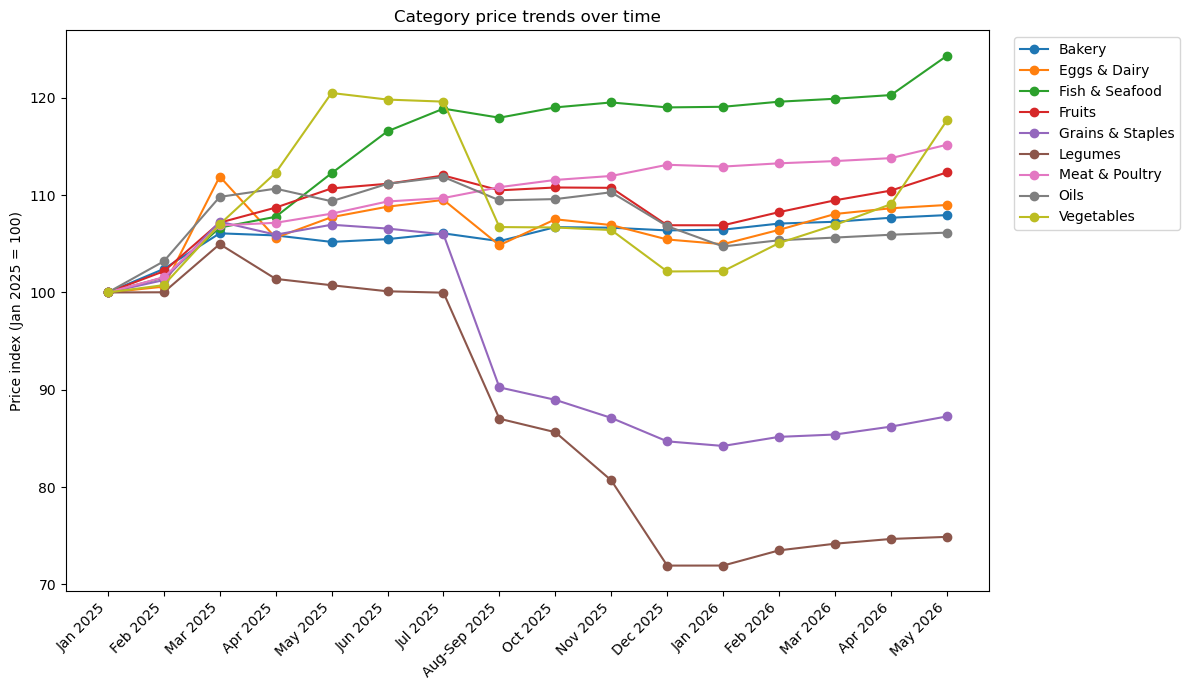

In [15]:
month_cols = ["Jan 2025", "Feb 2025", "Mar 2025", "Apr 2025", "May 2025", "Jun 2025",
              "Jul 2025", "Aug-Sep 2025", "Oct 2025", "Nov 2025", "Dec 2025", "Jan 2026",
              "Feb 2026", "Mar 2026", "Apr 2026", "May 2026"]

# index every item to 100 at its starting point, so items at very different
# price levels (rice vs tomatoes) can sit on the same scale
indexed = food_clean.set_index("item")[month_cols]
indexed = indexed.div(indexed["Jan 2025"], axis=0) * 100
indexed["category"] = food_clean.set_index("item")["category"]

category_over_time = indexed.groupby("category")[month_cols].mean()

plt.figure(figsize=(12, 7))
for cat, row in category_over_time.iterrows():
    plt.plot(month_cols, row, marker="o", label=cat)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Price index (Jan 2025 = 100)")
plt.title("Category price trends over time")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Step 4: Screening potential drivers

I screened several potential drivers before selecting the variables used in the analysis.

| Potential factor | Why considered | Data available? | Decision |
|---|---|---|---|
| Exchange rate | A weaker naira raises the cost of imported food and inputs | Yes, via a market-quoted proxy | **Included** |
| Fuel (petrol) price | Fuel moves food from farms to markets, so it can affect prices even for local produce | Yes, NBS publishes this monthly | **Included** |
| Rainfall / weather | Affects crop supply | No reliable monthly national series found | Excluded |
| Insecurity in farming regions | Can disrupt supply | No clean monthly national number found | Excluded |
| Global commodity prices | Nigeria imports some staples | Sourcing a separate international dataset wasn't realistic in this timeframe | Excluded |
| Seasonality (calendar month) | Agricultural prices are often cyclical | Only 17 months of data - not enough to tell a real seasonal pattern from a one-off | Not tested |

Based on this screening, I used exchange rate and petrol price as the two potential drivers in the analysis.

In [16]:
import datetime

# NBS petrol price data is collected separately for each available month
fuel_files = [
    {"month": "Jan 2025", "url": "https://microdata.nigerianstat.gov.ng/index.php/catalog/157/download/1164/PMS_Jan_2025.xlsx", "zipped": False},
    {"month": "Feb 2025", "url": "https://microdata.nigerianstat.gov.ng/index.php/catalog/157/download/1166/PMS_FEB_2025.xlsx", "zipped": False},
    {"month": "Mar 2025", "url": "https://microdata.nigerianstat.gov.ng/index.php/catalog/157/download/1203/PMS%20Report%20March%202025.xlsx", "zipped": False},
    {"month": "Apr 2025", "url": "https://microdata.nigerianstat.gov.ng/index.php/catalog/157/download/1215/Fuel_Report_April_2025.xlsx", "zipped": False},
    {"month": "May 2025", "url": "https://microdata.nigerianstat.gov.ng/index.php/catalog/157/download/1246/Fuel_Report_May_2025.xlsx", "zipped": False},
    {"month": "Jun 2025", "url": "https://microdata.nigerianstat.gov.ng/index.php/catalog/157/download/1261/PMS_Report_June_2025.xlsx", "zipped": False},
    {"month": "Jul 2025", "url": "https://microdata.nigerianstat.gov.ng/index.php/catalog/157/download/1277/PMS_Report_JULY_2025.zip", "zipped": True},
    {"month": "Aug-Sep 2025", "url": "https://microdata.nigerianstat.gov.ng/index.php/catalog/157/download/1357/PMS_Report_AUG_SEPT_2025.zip", "zipped": True},
    {"month": "Oct 2025", "url": "https://microdata.nigerianstat.gov.ng/index.php/catalog/157/download/1314/PMS%20Report%20OCTOBER%202025.zip", "zipped": True},
    {"month": "Nov 2025", "url": "https://microdata.nigerianstat.gov.ng/index.php/catalog/157/download/1328/PMS_REPORT_NOV_2025.zip", "zipped": True},
    {"month": "Dec 2025", "url": "https://microdata.nigerianstat.gov.ng/index.php/catalog/157/download/1345/PMS_DECEMBER_2025.zip", "zipped": True},
    {"month": "Jan 2026", "url": "https://microdata.nigerianstat.gov.ng/index.php/catalog/157/download/1358/PMS_Report_JANUARY_2026.zip", "zipped": True},
    {"month": "Feb 2026", "url": "https://microdata.nigerianstat.gov.ng/index.php/catalog/157/download/1374/PMS_Report_FEBRUARY_2026.zip", "zipped": True},
    {"month": "Mar 2026", "url": "https://microdata.nigerianstat.gov.ng/index.php/catalog/157/download/1398/PMS_Report_MARCH_2026.zip", "zipped": True},
    {"month": "Apr 2026", "url": "https://microdata.nigerianstat.gov.ng/index.php/catalog/157/download/1410/PMS_APRIL_2026.zip", "zipped": True},
    {"month": "May 2026", "url": "https://microdata.nigerianstat.gov.ng/index.php/catalog/157/download/1424/PMS_Report_MAY_2026.zip", "zipped": True},
]

fuel_rows = []

for entry in fuel_files:
    print(f"getting {entry['month']}...")
    for attempt in range(3):
        try:
            response = requests.get(entry["url"], timeout=60)
            if entry["zipped"]:
                z = zipfile.ZipFile(io.BytesIO(response.content))
                xlsx_name = [n for n in z.namelist() if n.endswith(".xlsx")][0]
                raw_bytes = z.read(xlsx_name)
            else:
                raw_bytes = response.content

            df_raw = pd.read_excel(io.BytesIO(raw_bytes), sheet_name=0, header=None)

            # some months have an extra title row before the real headers -
            # find the row that actually starts with "State" instead of assuming row 0
            header_row = None
            for i in range(min(30, len(df_raw))):
                if str(df_raw.iloc[i, 0]).strip().lower().startswith("state"):
                    header_row = i
                    break

            df = df_raw.iloc[header_row + 1:].copy()
            df.columns = df_raw.iloc[header_row]

            first_col = df.columns[0]
            avg_row = df[df[first_col].astype(str).str.strip().str.upper() == "AVERAGE"].iloc[0]

            # dates come through as real datetime objects in some files, plain text in others -
            # skipping any blank column names so they don't sneak into the date check
            date_cols = []
            for c in df.columns:
                if pd.isna(c):
                    continue
                if isinstance(c, (pd.Timestamp, datetime.datetime)):
                    date_cols.append(c)
                else:
                    try:
                        pd.to_datetime(c)
                        date_cols.append(c)
                    except Exception:
                        pass

            current_col = sorted(date_cols)[-1]
            fuel_rows.append({"month": entry["month"], "fuel_price": avg_row[current_col]})
            print(f"  got it: {avg_row[current_col]}")
            break
        except Exception as e:
            print(f"  attempt {attempt+1} failed: {e}")
            time.sleep(5)

fuel = pd.DataFrame(fuel_rows)
fuel.to_csv("food_data/combined_fuel_prices.csv", index=False)
fuel

getting Jan 2025...
  got it: 1258.3446139544
getting Feb 2025...
  got it: 1245.80113436542
getting Mar 2025...
  got it: 1261.64576720815
getting Apr 2025...
  got it: 1239.3271114285071
getting May 2025...
  got it: 1027.7573777589457
getting Jun 2025...
  got it: 1037.6594291327074
getting Jul 2025...
  got it: 1024.9930062617211
getting Aug-Sep 2025...
  got it: 970.5879660649986
getting Oct 2025...
  got it: 1052.311547273941
getting Nov 2025...
  got it: 1061.3500169049423
getting Dec 2025...
  got it: 1048.6271376644258
getting Jan 2026...
  got it: 1034.7558449707458
getting Feb 2026...
  got it: 1051.4722455965084
getting Mar 2026...
  got it: 1288.5421005331152
getting Apr 2026...
  got it: 1532.92621691899
getting May 2026...
  got it: 1596.2458192931645


,month,fuel_price
0,Jan 2025,1258.344614
1,Feb 2025,1245.801134
2,Mar 2025,1261.645767
3,Apr 2025,1239.327111
4,May 2025,1027.757378
5,Jun 2025,1037.659429
6,Jul 2025,1024.993006
7,Aug-Sep 2025,970.587966
8,Oct 2025,1052.311547
9,Nov 2025,1061.350017


### Adding the exchange rate

I used monthly closing USD/NGN rates from Investing.com because I could not obtain a usable monthly series directly from CBN. The series is therefore treated as a market-quoted proxy.

In [17]:
exchange_rate = pd.DataFrame({
    "month": ["Jan 2025", "Feb 2025", "Mar 2025", "Apr 2025", "May 2025", "Jun 2025",
              "Jul 2025", "Aug 2025", "Sep 2025", "Oct 2025", "Nov 2025", "Dec 2025",
              "Jan 2026", "Feb 2026", "Mar 2026", "Apr 2026", "May 2026"],
    "usd_ngn_rate": [1481.000, 1503.220, 1537.770, 1602.390, 1587.950, 1536.375,
                      1530.895, 1536.950, 1483.175, 1446.810, 1447.335, 1444.570,
                      1386.455, 1361.880, 1386.460, 1375.735, 1371.885]
})

exchange_rate.to_csv("food_data/exchange_rate.csv", index=False)
exchange_rate

,month,usd_ngn_rate
0,Jan 2025,1481.000
1,Feb 2025,1503.220
2,Mar 2025,1537.770
3,Apr 2025,1602.390
4,May 2025,1587.950
5,Jun 2025,1536.375
6,Jul 2025,1530.895
7,Aug 2025,1536.950
8,Sep 2025,1483.175
9,Oct 2025,1446.810


### Putting everything together

I merged the datasets by month so that each row represents one month in the study period.

In [18]:

fuel = pd.read_csv("food_data/combined_fuel_prices.csv")

# NBS reported August and September 2025 together, so the same reported
# value is assigned to both months
combined_row = fuel[fuel["month"] == "Aug-Sep 2025"].iloc[0]
aug_row = pd.DataFrame({"month": ["Aug 2025"], "fuel_price": [combined_row["fuel_price"]]})
sep_row = pd.DataFrame({"month": ["Sep 2025"], "fuel_price": [combined_row["fuel_price"]]})

fuel = fuel[fuel["month"] != "Aug-Sep 2025"]
fuel = pd.concat([fuel, aug_row, sep_row], ignore_index=True)

# cpi's month column is separate year/month, need one matching label to merge on
cpi_for_merge = cpi.copy()
cpi_for_merge["month"] = cpi_for_merge["month"] + " " + cpi_for_merge["year"].astype(str)

merged = cpi_for_merge[["month", "all_items_yoy", "food_yoy"]].merge(
    exchange_rate, on="month", how="left"
).merge(
    fuel, on="month", how="left"
)

merged

,month,all_items_yoy,food_yoy,usd_ngn_rate,fuel_price
0,Jan 2025,27.606151,29.625233,1481.000,1258.344614
1,Feb 2025,26.274415,26.98238,1503.220,1245.801134
2,Mar 2025,27.350063,25.219883,1537.770,1261.645767
3,Apr 2025,26.81593,24.675047,1602.390,1239.327111
4,May 2025,26.061316,24.554118,1587.950,1027.757378
5,Jun 2025,25.286661,25.407808,1536.375,1037.659429
6,Jul 2025,24.940533,26.195647,1530.895,1024.993006
7,Aug 2025,23.141652,25.304828,1536.950,970.587966
8,Sep 2025,20.980827,20.161952,1483.175,970.587966
9,Oct 2025,18.967917,16.302009,1446.810,1052.311547


### Note on August-September 2025

NBS published fuel prices for these two months as one combined report, so both months share the same value here. This means August and September should not be treated as fully independent fuel-price observations.

### Comparing food, exchange rate and fuel on the same scale

The three variables use different units, so their raw values cannot be compared directly. I indexed each series to 100 in January 2025 to compare their relative movements.

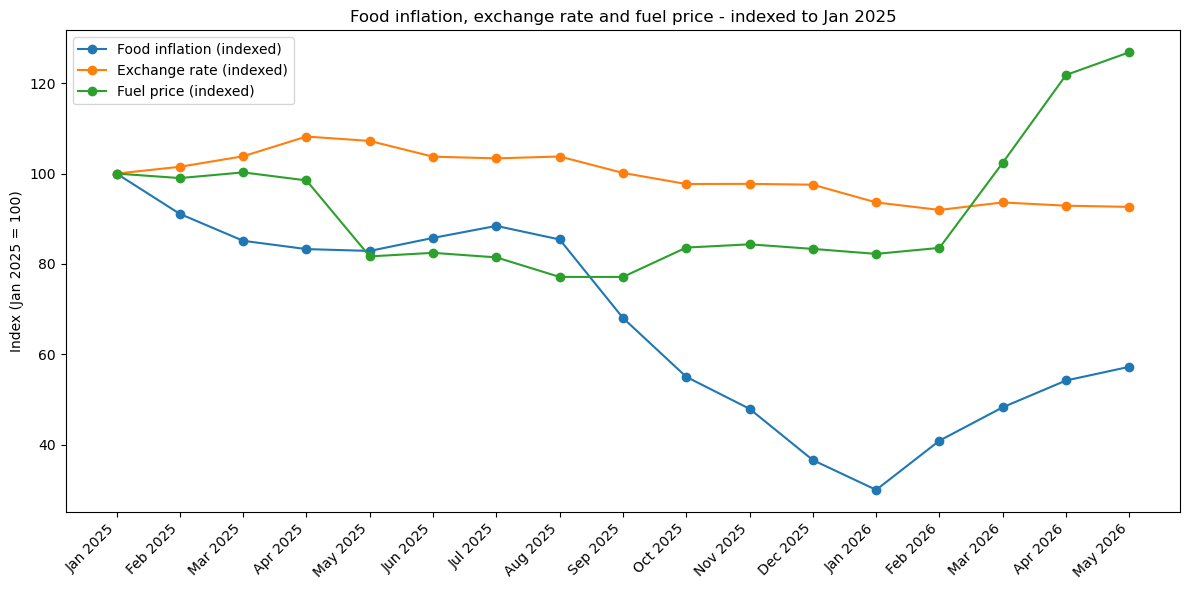

In [19]:
idx = merged.copy()
idx["food_index"] = idx["food_yoy"] / idx["food_yoy"].iloc[0] * 100
idx["fx_index"] = idx["usd_ngn_rate"] / idx["usd_ngn_rate"].iloc[0] * 100
idx["fuel_index"] = idx["fuel_price"] / idx["fuel_price"].iloc[0] * 100

plt.figure(figsize=(12, 6))
plt.plot(idx["month"], idx["food_index"], marker="o", label="Food inflation (indexed)")
plt.plot(idx["month"], idx["fx_index"], marker="o", label="Exchange rate (indexed)")
plt.plot(idx["month"], idx["fuel_index"], marker="o", label="Fuel price (indexed)")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Index (Jan 2025 = 100)")
plt.title("Food inflation, exchange rate and fuel price - indexed to Jan 2025")
plt.legend()
plt.tight_layout()
plt.show()

Food inflation is also different from the other two series because it is an inflation rate rather than a price level. The chart is therefore a visual comparison of how each series changed relative to its January 2025 value.

## Step 5: Correlation and regression

I then calculate the correlations between food inflation, exchange rate, and petrol price. Because there are only 17 monthly observations, the regression is treated as exploratory rather than as the main analysis.

In [20]:
correlations = merged[["food_yoy", "usd_ngn_rate", "fuel_price"]].corr()
correlations

,food_yoy,usd_ngn_rate,fuel_price
food_yoy,1.000000,0.782669,0.000952
usd_ngn_rate,0.782669,1.000000,-0.364569
fuel_price,0.000952,-0.364569,1.000000


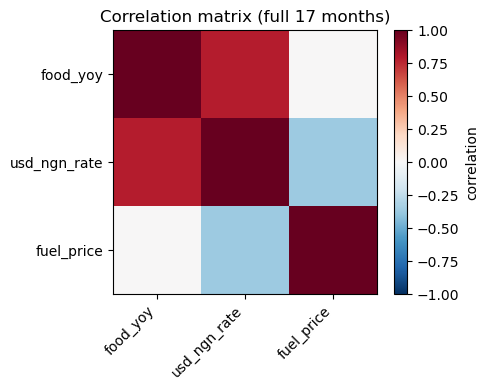

In [21]:
plt.figure(figsize=(5, 4))
plt.imshow(correlations, cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(label="correlation")
plt.xticks(range(len(correlations.columns)), correlations.columns, rotation=45, ha="right")
plt.yticks(range(len(correlations.index)), correlations.index)
plt.title("Correlation matrix (full 17 months)")
plt.tight_layout()
plt.show()

Correlation measures how strongly two variables move together - it doesn't,
on its own, establish that one causes the other.

### Checking correlation just for the reversal period

I also calculated the correlation specifically for January–May 2026, which covers the reversal period.

In [22]:
reversal_period = merged[merged["month"].isin(["Jan 2026", "Feb 2026", "Mar 2026", "Apr 2026", "May 2026"])]
reversal_period[["food_yoy", "usd_ngn_rate", "fuel_price"]].corr()

,food_yoy,usd_ngn_rate,fuel_price
food_yoy,1.000000,-0.262823,0.934146
usd_ngn_rate,-0.262823,1.000000,-0.061090
fuel_price,0.934146,-0.061090,1.000000


### Reversal-period correlation

During January–May 2026, petrol price had a correlation of 0.93 with food inflation, while the exchange rate had a correlation of -0.26. However, this calculation uses only five monthly observations, so the result should be treated as exploratory.

## Step 6: Robustness check

I repeated the correlation after removing each month one at a time. The resulting correlations ranged from 0.90 to 0.997. The relationship therefore remained strong across these leave-one-month-out checks.

In [23]:
reversal_months = ["Jan 2026", "Feb 2026", "Mar 2026", "Apr 2026", "May 2026"]

print("correlation using all 5 months:", round(reversal_period["food_yoy"].corr(reversal_period["fuel_price"]), 3))
print()

for month_to_drop in reversal_months:
    subset = reversal_period[reversal_period["month"] != month_to_drop]
    corr_without = subset["food_yoy"].corr(subset["fuel_price"])
    print(f"without {month_to_drop}: {round(corr_without, 3)}")

correlation using all 5 months: 0.934

without Jan 2026: 0.997
without Feb 2026: 0.971
without Mar 2026: 0.943
without Apr 2026: 0.922
without May 2026: 0.902


### Exploratory regression during the reversal

I use a simple regression to quantify the relationship above. The regression uses only five monthly observations, so the estimates should be treated as exploratory. Coefficient estimates from five points can be unstable, and the model cannot establish causation even where the relationship looks strong.

In [24]:
import statsmodels.formula.api as smf

merged["food_yoy"] = pd.to_numeric(merged["food_yoy"], errors="coerce")
merged["all_items_yoy"] = pd.to_numeric(merged["all_items_yoy"], errors="coerce")

reversal_period = merged[merged["month"].isin(["Jan 2026", "Feb 2026", "Mar 2026", "Apr 2026", "May 2026"])]

model = smf.ols("food_yoy ~ fuel_price", data=reversal_period).fit()
model.summary()

C:\Users\DAVID\anaconda3\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               food_yoy   R-squared:                       0.873
Model:                            OLS   Adj. R-squared:                  0.830
Method:                 Least Squares   F-statistic:                     20.55
Date:                Thu, 01 Oct 2026   Prob (F-statistic):             0.0201
Time:                        20:19:55   Log-Likelihood:                -7.2751
No. Observations:                   5   AIC:                             18.55
Df Residuals:                       3   BIC:                             17.77
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.4040      3.378     -0.416      0.706     -12.154       9.346
fuel_price     0.0116      0.003      4.534      0.020       0.003       0.020
==============================================================================
Omnibus:                          nan   Durbin-Watson:                   1.990
Prob(Omnibus):                    nan   Jarque-Bera (JB):                0.298
Skew:                          -0.361   Prob(JB):                        0.862
Kurtosis:                       2.047   Cond. No.                     7.46e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 7.46e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### What the regression says

The regression gives an R² of 0.873 for petrol price and food inflation during the five-month reversal period. The estimated coefficient is about 0.012 percentage points of food inflation per ₦1 change in petrol price. However, this estimate is based on only five observations and should not be interpreted as evidence that petrol prices caused 87% of the change in food inflation.

In [25]:
model_fx = smf.ols("food_yoy ~ usd_ngn_rate", data=reversal_period).fit()
model_fx.summary()

C:\Users\DAVID\anaconda3\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               food_yoy   R-squared:                       0.069
Model:                            OLS   Adj. R-squared:                 -0.241
Method:                 Least Squares   F-statistic:                    0.2226
Date:                Thu, 01 Oct 2026   Prob (F-statistic):              0.669
Time:                        20:19:56   Log-Likelihood:                -12.248
No. Observations:                   5   AIC:                             28.50
Df Residuals:                       3   BIC:                             27.71
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept      126.4759    239.103      0.529      0.633    -634.457     887.409
usd_ngn_rate    -0.0820      0.174     -0.472      0.669      -0.635       0.471
==============================================================================
Omnibus:                          nan   Durbin-Watson:                   0.515
Prob(Omnibus):                    nan   Jarque-Bera (JB):                0.707
Skew:                          -0.383   Prob(JB):                        0.702
Kurtosis:                       1.325   Cond. No.                     2.03e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.03e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### Exchange rate vs fuel, side by side

During the reversal period, the exchange rate had a weak correlation with food inflation (−0.26) and a low R² (0.069). Petrol price showed a much stronger association (r = 0.93, R² = 0.873). Given the small sample, these results should be treated as exploratory.

## Step 7: Findings

**Finding 1 - Did food inflation behave differently from headline inflation?**
Yes. Both eased through most of 2025, but food inflation swung much harder:
it fell to its lowest point in the study period (8.89%) in January 2026, then climbed back up to 16.96% by May 2026. Headline inflation barely moved over that same stretch, staying flat around 15%.

**Finding 2 - Which foods changed the most?**
Ranking all 42 items by their price change from Jan 2025 to May 2026 shows a wide spread - some items moved far more than others (see the ranking chart in Step 2). This shows how widely price changes varied across individual foods before the category analysis.

**Finding 3 - Which food categories changed the most during the reversal?**
Vegetables changed the most during the reversal window (nearly 16%), well ahead of every other group. Grains and staples showed much smaller average changes over the same period.

**Finding 4 - Which potential factors were associated with the movement?**
Of the two drivers tested:
- Exchange rate: weak correlation (-0.26), low R-squared (0.069), not
  statistically significant during the reversal window.
- Fuel price: strong correlation (0.93, still holds after removing any one
  month), high R-squared (0.873), statistically significant (p = 0.020).

Petrol price shows a much stronger association with food inflation during the five-month reversal than the exchange rate does. This is an observed statistical relationship; the analysis does not establish why the relationship exists. This is fuel (petrol) price specifically, not a direct measure of transport fares, which weren't part of this dataset.

### What this analysis cannot establish

- 17 months is a short time series, and the 5-month reversal regression is
  especially small - both estimates should be read as exploratory, not
  precise.
- Observational data like this cannot establish causation, even when the correlation is strong.
- The exchange rate data is a market-quoted proxy, not an official CBN
  series, since CBN's own portal couldn't be used for bulk extraction.
- Only two drivers were tested. Other real factors (insecurity, weather,
  local supply shocks, global commodity prices) weren't included because
  reliable monthly national data for them doesn't exist.
- Potential drivers may be correlated with each other in ways this analysis
  doesn't untangle - exchange rate and fuel price could both be moving
  because of some third factor, rather than independently.
- A stronger claim than "associated with" would need more data, a longer
  time frame, and ideally more than two candidate variables.